# This notebook runs the written code on the real data.
## Let us begin gently and say we only try this on 10 features.

## First, we will load the dataset and extract the top 10 genes.
## Second, we do the fitting just as before.
## Third, we do this for many different draws of the dataset.  Instead of fighting with 15k data simultaneously, it's better to have 300 data points run over 50 fitting attempts.
### Everything is written in PyTorch Tensors.  While clumsy to write, it does appear to run much faster.

In [1]:
# Import packages
import numpy as np
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.linalg import cholesky, solve_triangular, det
import torch
from torch.autograd import Function
from torch.linalg import cholesky, solve_triangular
import torch.optim as optim
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import sys
import random
from scipy.special import kv, kvp, gamma
from scipy.special import beta as B
from scipy.spatial.distance import pdist, squareform
from scipy.stats import multivariate_normal
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.interpolate import griddata
from scipy.linalg import cho_solve, cho_factor
from scipy.optimize import minimize

In [9]:
# Load the H5AD file
adata_original = sc.read_h5ad('ovary_Puck_230517_39.h5ad')
# adata_original = sc.read_h5ad('mouse_ovary_slide_seq_young_estrus.h5ad')

adata = adata_original

def isolate_gene_values (gene_name):
    gene_values = pd.DataFrame(adata[:, gene_name].X.toarray(), columns=[gene_name], index=adata.obs_names)
    return gene_values

coordinates = pd.DataFrame(adata.obsm["spatial"], columns=['x', 'y'], index=adata.obs_names)

df = pd.concat([
    coordinates,
    isolate_gene_values("Serpine2"),
    isolate_gene_values("Tagln"),
    isolate_gene_values("Acta2"),
    isolate_gene_values("Mgp"),
    isolate_gene_values("S100a6"),
    isolate_gene_values("Col1a2"),
    isolate_gene_values("Nr5a2"),
    isolate_gene_values("Inhba"),
    isolate_gene_values("Tpm2"),
    isolate_gene_values("Tdrd5")
], axis=1)

df = df.sample(frac=1)
# df = df.head(15000)

df['x'] = df['x'] / df['x'].median()
df['y'] = df['y'] / df['y'].median()

# Normalize all gene columns by dividing by 1000
genes_to_normalize = ["Serpine2", "Tagln", "Acta2", "Mgp", "S100a6", "Col1a2", "Nr5a2", "Inhba", "Tpm2", "Tdrd5"]
for gene in genes_to_normalize:
    df[gene] = df[gene] / 1000

df

,x,y,Serpine2,Tagln,Acta2,Mgp,S100a6,Col1a2,Nr5a2,Inhba,Tpm2,Tdrd5
ATTTACTCCGCTAA-1-2,1.355102,1.214836,0.000000,0.000000,0.000000,0.874126,0.0,0.174825,0.000000,0.0,0.000000,0.0
GTGTACNCGTGTCG-1-2,1.045038,0.505700,0.540541,0.000000,0.000000,0.000000,0.0,0.270270,0.000000,0.0,0.810811,0.0
CTNCAAGGAACCAG-1-2,0.566182,1.153687,0.000000,0.909091,0.909091,0.909091,0.0,0.681818,0.000000,0.0,0.681818,0.0
AGCGGTTATAGAGT-1-2,0.775408,0.788903,0.215054,0.215054,0.000000,0.215054,0.0,0.215054,0.000000,0.0,0.000000,0.0
TACATGCCACCAAG-1-2,0.875153,0.903798,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
TGTCATAAATGTGA-1-2,1.077359,1.234121,0.000000,0.520833,0.000000,0.000000,0.0,0.520833,0.000000,0.0,0.000000,0.0
AGGGGCGGCAACCT-1-2,1.314535,1.028650,0.000000,0.000000,0.000000,0.904977,0.0,0.226244,0.000000,0.0,0.226244,0.0
CATCCCACCTGGTA-1-2,1.122661,1.094907,0.275672,0.000000,0.000000,0.000000,0.0,0.068918,0.068918,0.0,0.000000,0.0
GTTCCTTACGGGTC-1-2,0.920191,0.809224,0.000000,0.000000,0.000000,0.293255,0.0,0.000000,0.000000,0.0,0.000000,0.0


In [10]:
# # Global parameters:
number_of_steps = 1000 # how many steps to run in optimisation
number_of_groups = 10 # divide the data set into smaller ones, to make fitting easier.


# number_of_simulations = 100 # how many optimisation to average over
# number_of_locations = 100 # how many locations to observe
# dims = 2  # 2D spatial
# p =  10 # how many features 

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# Extract the X and Y data

In [12]:
def is_positive_definite(matrix):
    """Check if a matrix is positive definite."""
    try:
        torch.linalg.cholesky(matrix)
        return True
    except RuntimeError:
        return False

In [13]:
# # Now simulate in pytorch number_of_locations locations
# def simulate_locations(number_of_locations, dimensions=2, range_min=-3.0, range_max=3.0):
#     """
#     Simulates random locations within a specified range.

#     Parameters:
#     - number_of_locations (int): The number of locations to simulate.
#     - dimensions (int): The number of dimensions for each location (e.g., 2 for 2D, 3 for 3D).
#     - range_min (float): The minimum value for the location coordinates.
#     - range_max (float): The maximum value for the location coordinates.

#     Returns:
#     - locations (torch.Tensor): A tensor of shape (number_of_locations, dimensions) containing the simulated locations.
#     """
#     # Generate random locations within the specified range
#     locations = torch.FloatTensor(number_of_locations, dimensions).uniform_(range_min, range_max)
#     return locations
# # Example usage
# X = simulate_locations(number_of_locations, dims)
# print("Simulated Locations:\n", X)

In [14]:
# Convert 'x' and 'y' columns into a tensor
X = torch.tensor(df[['x', 'y']].values, dtype=torch.float32)

X

tensor([[1.3551, 1.2148],
        [1.0450, 0.5057],
        [0.5662, 1.1537],
        ...,
        [1.1227, 1.0949],
        [0.9202, 0.8092],
        [0.7921, 0.9740]])

In [15]:
len(X)

15907

In [8]:
# Define the custom autograd function for the Bessel function of the second kind
class BesselKFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, v, x):
        # Store v and x for the backward pass
        ctx.save_for_backward(v, x)
        
        # Convert tensors to numpy for SciPy compatibility
        x_np = x.detach().cpu().numpy()
        v_np = v.detach().cpu().numpy()
        
        # Compute the Bessel function using SciPy
        output = torch.tensor(kv(v_np, x_np), dtype=torch.float32)
        
        # Return the output as a tensor
        return output.to(x.device)

    @staticmethod
    def backward(ctx, grad_output):
        # Retrieve saved tensors
        v, x = ctx.saved_tensors
        
        # Convert tensors to numpy for gradient calculations
        x_np = x.detach().cpu().numpy()
        v_np = v.detach().cpu().numpy()
        
        # Numerical derivative with respect to x
        epsilon_x = 1e-7
        grad_x = (kv(v_np, x_np + epsilon_x) - kv(v_np, x_np - epsilon_x)) / (2 * epsilon_x)
        grad_x = torch.tensor(grad_x, dtype=torch.float32).to(x.device)
        
        # Derivative with respect to v (using kvp, which gives the derivative of kv with respect to v)
        grad_v = torch.tensor(kvp(v_np, x_np), dtype=torch.float32).to(v.device)
        
        # Multiply by the incoming gradient (chain rule)
        grad_input_x = grad_output * grad_x
        grad_input_v = grad_output * grad_v
        
        return grad_input_v, grad_input_x

def matern_kernel(pairwise_distances, nu, length_scale, sigma2, epsilon=1e-6):
    """
    Computes the Matérn covariance matrix with support for broadcasting over nu, length_scale, and sigma2.

    Parameters:
    - pairwise_distances (torch.Tensor): Pairwise distances, shape (n_locations, n_locations) or broadcasted to (p, p, n_locations, n_locations).
    - nu (torch.Tensor): Smoothness parameter, can be broadcasted (e.g., shape (p, p, 1, 1)).
    - length_scale (torch.Tensor): Length scale parameter, can be broadcasted (e.g., shape (p, p, 1, 1)).
    - sigma2 (torch.Tensor): Variance parameter, can be broadcasted (e.g., shape (p, p, 1, 1)).
    - epsilon (float): A small perturbation to ensure nu != 0.5.

    Returns:
    - covariance_matrix (torch.Tensor): The computed Matérn covariance matrix, with shape depending on input broadcasting.
    """

    # Add a tiny perturbation to nu if it's exactly 0.5
    nu = torch.where(nu == 0.5, nu + epsilon, nu)

    # Compute the scaled distances using broadcasting
    scaled_distances = torch.sqrt(2 * nu) * (pairwise_distances / length_scale)
    
    # Clamp the values of scaled_distances to avoid extreme numbers
    scaled_distances = torch.clamp(scaled_distances, min=1e-9, max=1e6)

    # Use the custom Bessel function with autograd
    bessel_term = BesselKFunction.apply(nu, scaled_distances)
    scaling_term = (2 ** (1.0 - nu)) / torch.exp(torch.lgamma(nu))
    covariance_matrix = sigma2 * scaling_term * (scaled_distances ** nu) * bessel_term
    
    # Set diagonal elements where pairwise_distances == 0 to sigma2
    covariance_matrix = torch.where(pairwise_distances == 0, sigma2, covariance_matrix)
    
    return covariance_matrix

# Now that we have the alpha, nu, and sigma matrices, we want to define a function 
# Input are those three matrices, as well as X, the matrix of locations
# Output is the matern covariance matrix, computed by the function 
# matern_kernel(pairwise_distances, nu, length_scale, sigma2)
def compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X):
    """
    Computes the Matérn covariance matrix using the provided alpha, nu, and sigma matrices.

    Parameters:
    - alpha_matrix (torch.Tensor): The alpha matrix of shape (p, p).
    - nu_matrix (torch.Tensor): The nu matrix of shape (p, p).
    - sigma_matrix (torch.Tensor): The sigma matrix of shape (p, p).
    - X (torch.Tensor): The matrix of locations of shape (n_locations, dimensions).

    Returns:
    - K (torch.Tensor): The Matérn covariance matrix of shape (n_locations * p, n_locations * p).
    """
    n_locations = X.size(0)
    p = alpha_matrix.size(0)

    # Compute pairwise distances between locations (n_locations, n_locations)
    pairwise_distances = torch.cdist(X, X)
    
    # Expand pairwise distances to (p, p, n_locations, n_locations) for broadcasting
    pairwise_distances_expanded = pairwise_distances.unsqueeze(0).unsqueeze(0).expand(p, p, n_locations, n_locations)
    
    # Ensure the correct shapes for broadcasting
    nu_expanded = nu_matrix.unsqueeze(-1).unsqueeze(-1)  # Shape: (p, p, 1, 1)
    alpha_expanded = alpha_matrix.unsqueeze(-1).unsqueeze(-1)  # Shape: (p, p, 1, 1)
    sigma_expanded = sigma_matrix.unsqueeze(-1).unsqueeze(-1)  # Shape: (p, p, 1, 1)

    # Compute the covariance matrix using broadcasting
    K_blocks = matern_kernel(
        pairwise_distances_expanded, 
        nu_expanded,  
        alpha_expanded,  
        sigma_expanded
    )
    
    # Reshape to create the block covariance matrix (n_locations * p, n_locations * p)
    K = K_blocks.permute(0, 2, 1, 3).reshape(p * n_locations, p * n_locations)
    
    return K
    
def compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma):
    """
    Computes p by p matrices alpha, nu, and sigma based on the provided parameters.

    Parameters:
    - Delta_A, Delta_B, rho_A, rho_B, rho_V (torch.float32): Scalars.
    - W, alpha, nu, sigma (torch.float32): 1D tensors of size p.

    Returns:
    - alpha_matrix, nu_matrix, sigma_matrix: p x p matrices of computed values.
    """
    p = W.size(0)
    dim = 2  # Given constant value

    # Calculate alpha_ij matrix
    alpha_i_squared = alpha.unsqueeze(1)**2  # shape: (p, 1)
    alpha_j_squared = alpha.unsqueeze(0)**2  # shape: (1, p)
    alpha_matrix = torch.sqrt((alpha_i_squared + alpha_j_squared) / 2 + Delta_B * (1 - rho_B))
    
    # Calculate nu_ij matrix
    nu_matrix = (nu.unsqueeze(1) + nu.unsqueeze(0)) / 2 + Delta_A * (1 - rho_A)
    
    # Calculate sigma_ij matrix
    W_i = W.unsqueeze(1)  # shape: (p, 1)
    W_j = W.unsqueeze(0)  # shape: (1, p)
    sigma_matrix = (
        W_i * W_j * rho_V * alpha_matrix ** (-2 * Delta_A - (nu.unsqueeze(0) + nu.unsqueeze(1))) *
        torch.exp(
            torch.lgamma((nu.unsqueeze(0) + nu.unsqueeze(1)) / 2 + dim / 2) +
            torch.lgamma(nu_matrix) -
            torch.lgamma(nu_matrix + dim / 2)
        )
    )    
    return alpha_matrix, nu_matrix, sigma_matrix

# # Example usage
# # Delta_A = torch.tensor(0.5, dtype=torch.float32, requires_grad=True)
# # Delta_B = torch.tensor(0.5, dtype=torch.float32, requires_grad=True)
# # rho_A = torch.tensor(0.5, dtype=torch.float32, requires_grad=True)
# # rho_B = torch.tensor(0.5, dtype=torch.float32, requires_grad=True)
# # rho_V = torch.tensor(0.8, dtype=torch.float32, requires_grad=True)


# # W = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32, requires_grad=True)
# # alpha = torch.tensor([0.2, 0.3, 0.4], dtype=torch.float32, requires_grad=True)
# # nu = torch.tensor([0.5, 0.6, 0.7], dtype=torch.float32, requires_grad=True)
# # sigma = torch.tensor([0.1, 0.2 , 0.3], dtype=torch.float32, requires_grad=True)

# def random_search_parameters(p, X, max_iterations=10000000):
#     """
#     Randomly searches for a combination of parameters that satisfies a given clause.
    
#     Parameters:
#     - p (int): The length of the list W (number of parameters W1 to Wp).
#     - clause_function (callable): A function that takes (Delta_A, Delta_B, rho_A, rho_B, rho_V, W) as inputs
#                                   and returns True if the clause is satisfied, False otherwise.
#     - max_iterations (int): The maximum number of random samples to test.

#     Returns:
#     - A tuple of PyTorch tensors if a solution is found.
#     - None if no solution is found within the max_iterations.
#     """
#     for _ in range(max_iterations):
#         # Generate random values for the parameters as PyTorch tensors
#         Delta_A = torch.tensor(random.uniform(0.001, 10), dtype=torch.float32).to(device)
#         Delta_B = torch.tensor(random.uniform(0.000, 10), dtype=torch.float32).to(device)
#         rho_A = torch.tensor(random.uniform(-.99, 0.99), dtype=torch.float32).to(device)
#         rho_B = torch.tensor(random.uniform(-.99, 0.99), dtype=torch.float32).to(device)
#         rho_V = torch.tensor(random.uniform(-.99, 0.99), dtype=torch.float32).to(device)
#         W = torch.tensor([random.uniform(0.001, 10) for _ in range(p)], dtype=torch.float32).to(device)
#         alpha = torch.tensor([random.uniform(0.001, 10) for _ in range(p)], dtype=torch.float32).to(device)
#         nu = torch.tensor([random.uniform(0.001, 10) for _ in range(p)], dtype=torch.float32).to(device)
#         sigma = torch.tensor([random.uniform(-10, 10) for _ in range(p)], dtype=torch.float32).to(device)
        
        
#         alpha_matrix, nu_matrix, sigma_matrix = compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma)
#         # Check if the clause is satisfied
#         K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
#         if is_positive_definite(K):
#             return Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma
    
#     # If no solution is found, return None
#     return None

# Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma = random_search_parameters(p,X)
# alpha_matrix, nu_matrix, sigma_matrix = compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma)

# print("Alpha matrix:\n", alpha_matrix)
# print("Nu matrix:\n", nu_matrix)
# print("Sigma matrix:\n", sigma_matrix)

# # Compute the Matérn covariance matrix
# K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
# print("Matérn covariance matrix K:\n", K)

In [9]:
# # Store values used in the ground_truths data frame for later comparison purposes
# data_dict = {}
# # Convert tensors to lists for storage in DataFrame
# data_dict = {
#     'Delta_A': Delta_A.item(),
#     'Delta_B': Delta_B.item(),
#     'rho_A': rho_A.item(),
#     'rho_B': rho_B.item(),
#     'rho_V': rho_V.item()
# }


# # Flatten matrices and add individual components to the data dictionary
# for i in range(W.size(0)):
#     data_dict[f'W_{i+1}'] = W[i].item()
# for i in range(alpha_matrix.size(0)):
#     for j in range(alpha_matrix.size(1)):
#         data_dict[f'alpha_matrix_{i+1}{j+1}'] = alpha_matrix[i, j].item()
#         data_dict[f'nu_matrix_{i+1}{j+1}'] = nu_matrix[i, j].item()
#         data_dict[f'sigma_matrix_{i+1}{j+1}'] = sigma_matrix[i, j].item()

# # Create a DataFrame to store the values
# ground_truth_df = pd.DataFrame([data_dict])

# # Display the DataFrame
# ground_truth_df

In [10]:
# # Now that we have X and K,  simulate p-variate data sampled at locations in X with a Gaussian process along Normal(0,K) 
# def simulate_gp_data(X, K):
#     """
#     Simulates a p-variate dataset sampled at locations in X with a Gaussian process.
    
#     Parameters:
#     - X (torch.Tensor): The matrix of locations of shape (n_locations, dimensions).
#     - K (torch.Tensor): The covariance matrix computed using the Matérn kernel of shape (n_locations * p, n_locations * p).

#     Returns:
#     - Y (torch.Tensor): The simulated dataset of shape (n_locations, p).
#     """
#     # Get the number of locations and the dimensionality of the data
#     n_locations = X.size(0)
#     p = K.size(0) // n_locations

#     # Sample from a multivariate normal distribution with mean 0 and covariance K
#     mean = torch.zeros(K.size(0), dtype=torch.float32)
#     Y = torch.distributions.MultivariateNormal(mean, covariance_matrix=K).rsample()

#     # Reshape the output to have shape (n_locations, p)
#     Y = Y.view(n_locations, p)

#     return Y
    
# # Simulate the p-variate data
# Y = simulate_gp_data(X, K)
# print("Simulated p-variate data Y:\n", Y)

In [11]:
# List of gene columns
genes_to_include = ["Serpine2", "Tagln", "Acta2", "Mgp", "S100a6", "Col1a2", "Nr5a2", "Inhba", "Tpm2", "Tdrd5"]

# Convert the gene columns into a tensor
Y = torch.tensor(df[genes_to_include].values, dtype=torch.float32)

Y

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0023, 0.0000, 0.0000,  ..., 0.0000, 0.0030, 0.0023],
        ...,
        [0.0038, 0.0000, 0.0000,  ..., 0.0041, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0015, 0.0015, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])

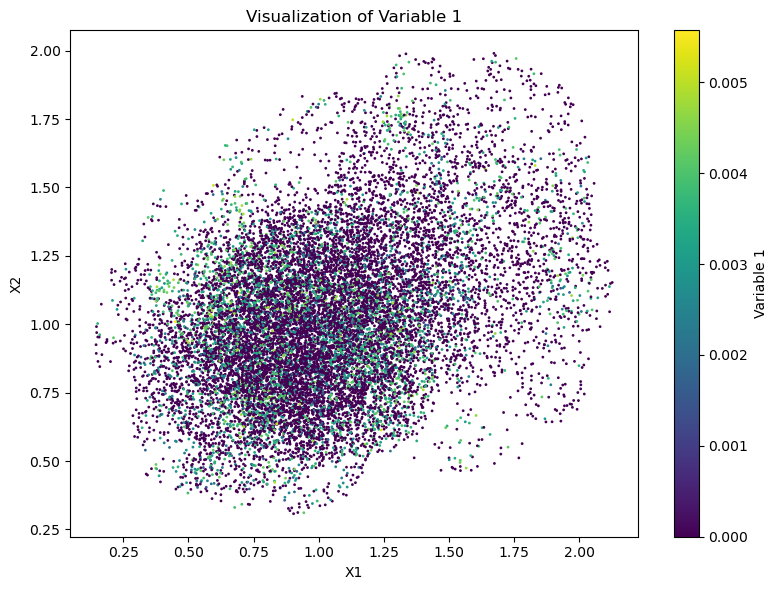

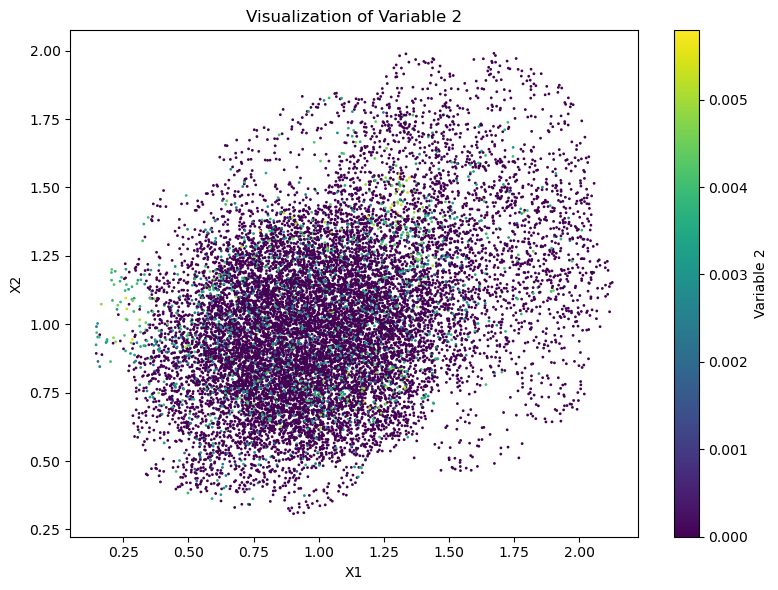

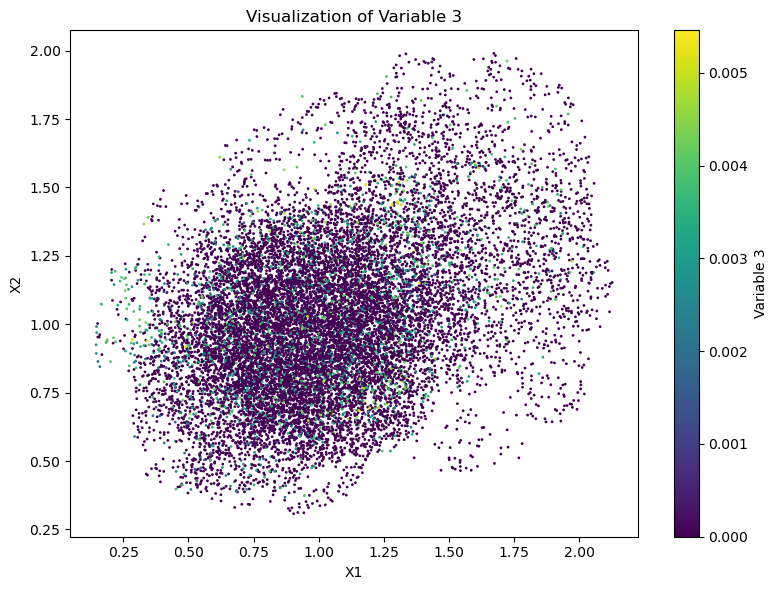

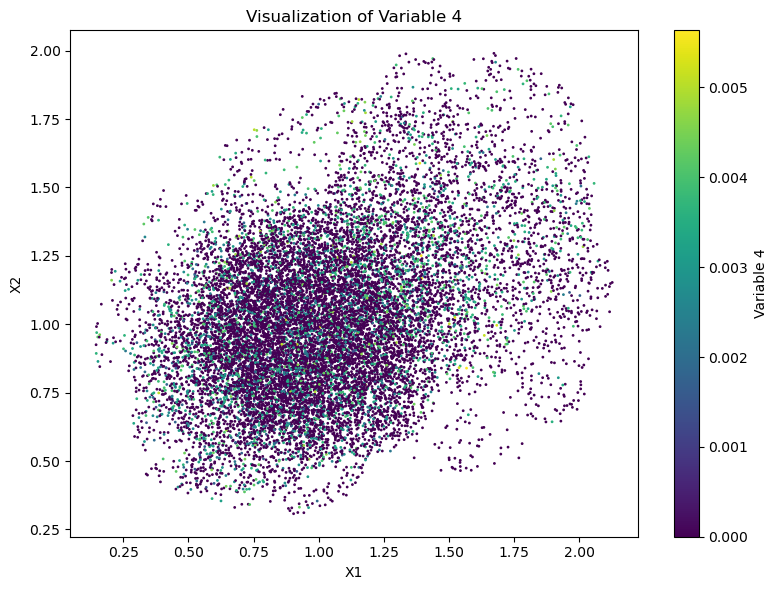

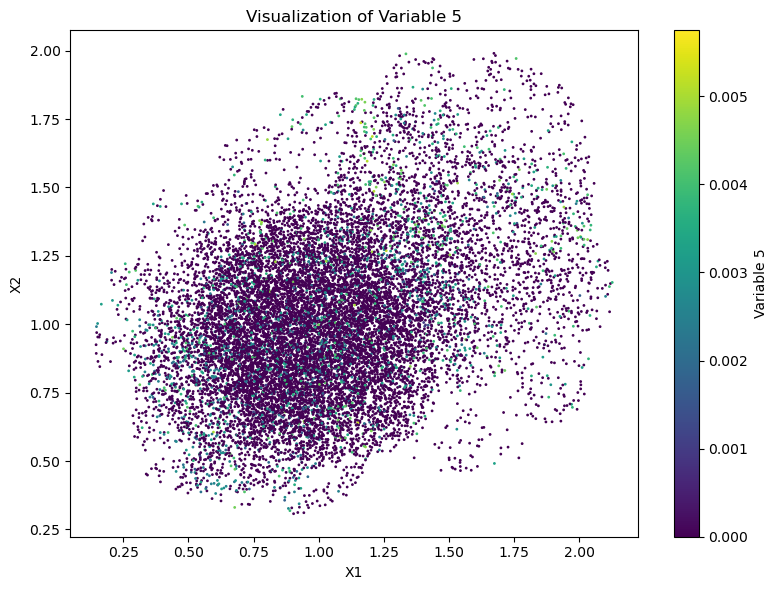

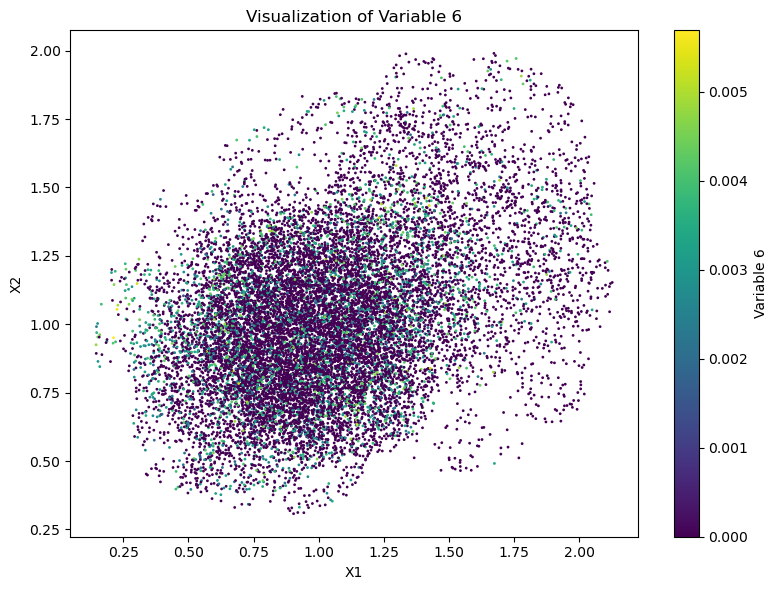

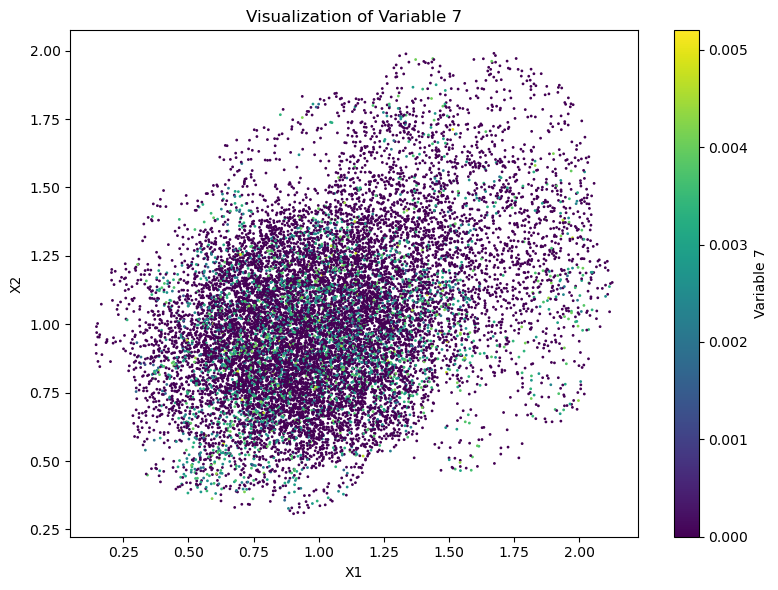

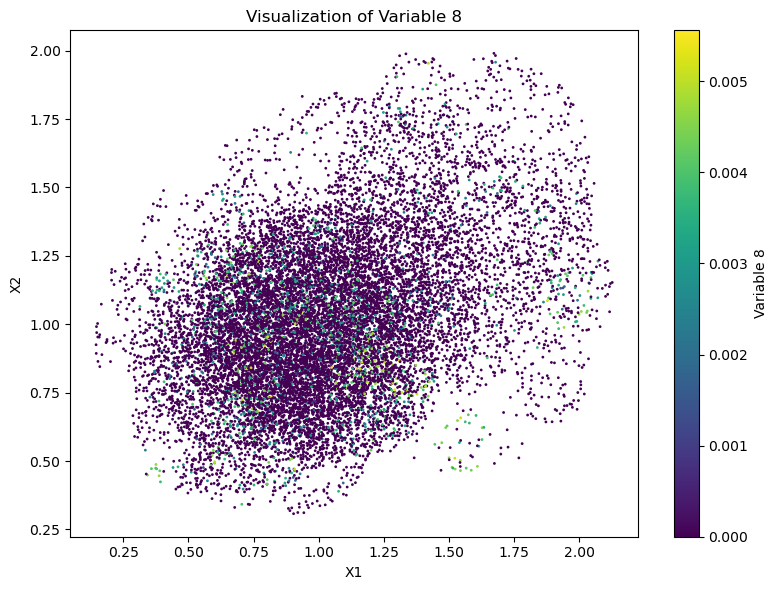

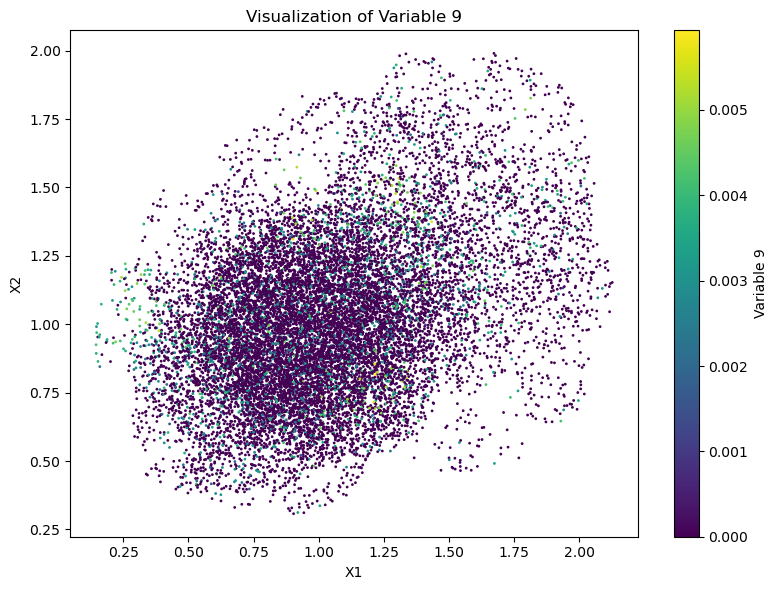

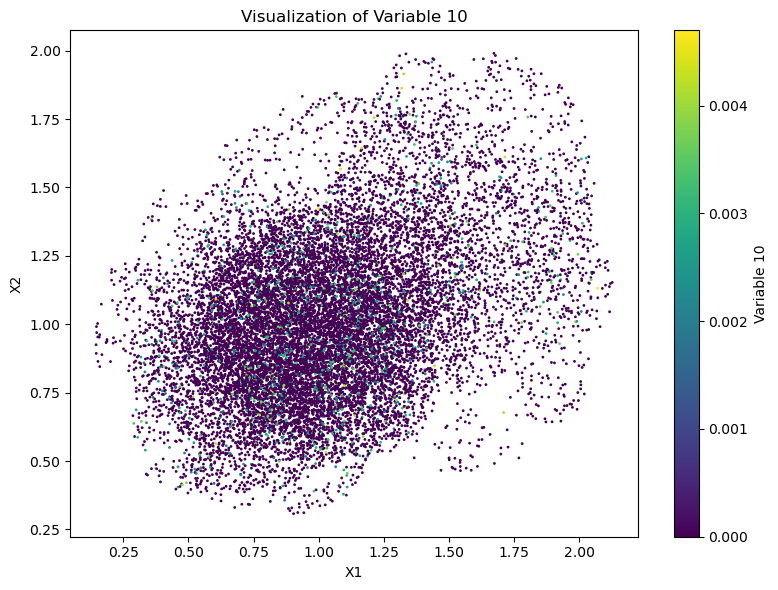

In [12]:
# Produce p plots so that I can visualise how these data look like
def plot_gp_data(X, Y):
    """
    Plots the p-variate data for each variable.
    
    Parameters:
    - X (torch.Tensor): The matrix of locations of shape (n_locations, dimensions).
    - Y (torch.Tensor): The simulated dataset of shape (n_locations, p).
    """
    p = Y.size(1)
    
    # Create a plot for each variable
    for i in range(p):
        plt.figure(figsize=(8, 6))
        if X.size(1) == 2:  # 2D locations
            plt.scatter(X[:, 0].detach().numpy(), X[:, 1].detach().numpy(), c=Y[:, i].detach().numpy(), cmap='viridis', s=1)
            plt.colorbar(label=f'Variable {i+1}')
            plt.xlabel('X1')
            plt.ylabel('X2')
        elif X.size(1) == 1:  # 1D locations
            plt.plot(X.detach().numpy(), Y[:, i].detach().numpy(), '-o')
            plt.xlabel('X')
            plt.ylabel(f'Variable {i+1}')
        
        plt.title(f'Visualization of Variable {i+1}')
        plt.tight_layout()
        plt.show()

# Plot the p-variate data
plot_gp_data(X, Y)

In [13]:
# Compute the negative log-likelihood loss
def negative_log_likelihood(y, cov_matrix):
    n = y.shape[0]
    L = cholesky(cov_matrix, upper=False)
    alpha = solve_triangular(L, y.reshape(-1, 1), upper=False)
    log_likelihood = 0.5 * torch.sum(alpha ** 2)
    log_likelihood += torch.sum(torch.log(torch.diag(L)))
    log_likelihood += 0.5 * n * torch.log(torch.tensor(2 * torch.pi))
    return log_likelihood
    
def optimize_marginal_parameters(X, Y):
    """
    Optimize the parameters alpha_i, nu_i, and sigma_i for each variable i by minimizing the NLL.
    
    Parameters:
    - X (torch.Tensor): Locations matrix of shape (n_locations, dimensions).
    - Y (torch.Tensor): Simulated data of shape (n_locations, p).
    
    Returns:
    - optimized_params (list): List of optimized (alpha, nu, sigma) for each variable.
    """
    p = Y.size(1)
    n_locations = X.size(0)
    
    optimized_params = []
    
    for i in range(p):
        # Initialize alpha_i, nu_i, and sigma_i with requires_grad=True for optimization
        alpha_i = torch.tensor(1.0, dtype=torch.float32, requires_grad=True).to(device)
        nu_i = torch.tensor(1.0, dtype=torch.float32, requires_grad=True).to(device)
        sigma_i = torch.tensor(1.0, dtype=torch.float32, requires_grad=True).to(device)
        
        # Define the optimizer
        optimizer = optim.Adam([alpha_i, nu_i, sigma_i], lr=0.0001)

        # Early stopping parameters
        tolerance = 1e-5 # Threshold for considering convergence
        patience = 25  # Number of epochs with no improvement to wait before stopping
        best_loss = float('inf')
        epochs_no_improve = 0
        
        # Optimization loop
        for epoch in range(1000):  # Number of iterations
            try:
                optimizer.zero_grad()
                # Compute the covariance matrix K
                K = matern_kernel(torch.cdist(X, X), nu_i, alpha_i, sigma_i)
                
                # Add a small noise for numerical stability
                K += torch.eye(n_locations) * 1e-6
                
                # Compute the NLL
                nll = negative_log_likelihood(Y[:, i], K)
                
                # Backpropagation
                nll.backward()

                # Gradient clipping
                torch.nn.utils.clip_grad_norm_([nu_i, alpha_i, sigma_i], max_norm=10.0)
                
                # Optimization step
                optimizer.step()          

                # Check for convergence for early stopping
                if nll.item() < best_loss - tolerance:
                    best_loss = nll.item()
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    # print(f"Early stopping at epoch {epoch}")
                    break

                # Print the loss every 100 epochs for monitoring
                # if epoch % 100 == 0:
                #     print(f'Epoch {epoch}, NLL: {nll.item()}')
            
            except Exception as e:
                # Report the parameters that led to the error
                print(f"Error encountered during epoch {epoch}: {e}")
                print(f"Parameters that caused the error -> nu_i: {nu_i}, alpha_i: {alpha_i}, sigma_i: {sigma_i}")
                
                # Optionally, break or continue
                break  # Stop the loop if you want to halt on error
        
        # Store the optimized parameters
        optimized_params.append((alpha_i.item(), nu_i.item(), sigma_i.item()))
    
    return optimized_params

In [14]:
# optimized_marginal_params = optimize_marginal_parameters(X, Y)
# for i, params in enumerate(optimized_marginal_params):
#     print(f"Optimized parameters for variable {i+1}: alpha_{i+1} = {params[0]}, nu_{i+1}= {params[1]}, sigma_{i+1} = {params[2]}")

In [15]:
def optimize_cross_parameters(optimized_marginal_params, X, Y):
    # Early stopping parameters
    tolerance = 1e-5  # Threshold for considering convergence
    patience = 25  # Number of epochs with no improvement to wait before stopping
    best_loss = float('inf')
    epochs_no_improve = 0

    # Number of variables (p can be arbitrary)
    p = Y.size(1)

    # Initialize the parameters to be optimized
    Delta_A = torch.tensor(0.001, dtype=torch.float32, requires_grad=True).to(device)
    Delta_B = torch.tensor(0.001, dtype=torch.float32, requires_grad=True).to(device)
    rho_A = torch.tensor(1.0, dtype=torch.float32, requires_grad=True).to(device)
    rho_B = torch.tensor(1.0, dtype=torch.float32, requires_grad=True).to(device)
    rho_V = torch.tensor(1.0, dtype=torch.float32, requires_grad=True).to(device)
    # W = torch.ones(p, dtype=torch.float32, requires_grad=True)

    W = (torch.ones(p, dtype=torch.float32, requires_grad=True) * 0.001).clone().detach().requires_grad_(True).to(device)

    # Extract the optimized alpha, nu, and sigma from the list
    alpha = torch.tensor([param[0] for param in optimized_marginal_params], dtype=torch.float32, requires_grad=False).to(device)
    nu = torch.tensor([param[1] for param in optimized_marginal_params], dtype=torch.float32, requires_grad=False).to(device)
    sigma = torch.tensor([param[2] for param in optimized_marginal_params], dtype=torch.float32, requires_grad=False).to(device)

    # Define the optimizer with a learning rate of 0.001
    optimizer = optim.Adam([Delta_A, Delta_B, rho_A, rho_B, rho_V, W], lr=0.001)

    # Optimization loop
    for epoch in range(1000):  # Number of iterations
        try:
            optimizer.zero_grad()

            # Step 1: Compute the parameter matrices
            alpha_matrix, nu_matrix, sigma_matrix = compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma)

            # Step 2: Compute the Matérn covariance matrix
            K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)

            # Step 3: Add a small noise for numerical stability
            K += torch.eye(X.size(0) * p) * 1e-6

            # Step 4: Compute the negative log likelihood (NLL)
            nll = negative_log_likelihood(Y, K)

            # Backpropagation
            nll.backward()

            # Gradient clipping (to avoid exploding gradients)
            torch.nn.utils.clip_grad_norm_([Delta_A, Delta_B, rho_A, rho_B, rho_V, W], max_norm=1.0)

            # Optimization step
            optimizer.step()

            # Check for convergence for early stopping
            if nll.item() < best_loss - tolerance:
                best_loss = nll.item()
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
            if epochs_no_improve >= patience:
                # print(f"Early stopping at epoch {epoch}")
                break

        except Exception as e:
            # Report the parameters that led to the error
            print(f"Error encountered during epoch {epoch}: {e}")
            print(f"Parameters that caused the error -> Delta_A: {Delta_A}, Delta_B: {Delta_B}, rho_A: {rho_A}, rho_B: {rho_B}, rho_V: {rho_V}, W: {W}")

            # Stop the loop if you want to halt on error
            break

    # After optimization, the parameters should be optimized for the given data
    # print("Optimized parameters:")
    # print(f"Delta_A: {Delta_A.item()}, Delta_B: {Delta_B.item()}, rho_A: {rho_A.item()}, rho_B: {rho_B.item()}, rho_V: {rho_V.item()}, W: {W.tolist()}")

    # Call the function to compute the parameter matrices with the final optimized and given parameters
    alpha_matrix, nu_matrix, sigma_matrix = compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma)

    K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
    if not is_positive_definite(K):
        print("Warning: K is not positive definite.")

    # Initialize a dictionary to store the estimated parameters
    estimated_params_dict = {
        'Delta_A': Delta_A.item(),
        'Delta_B': Delta_B.item(),
        'rho_A': rho_A.item(),
        'rho_B': rho_B.item(),
        'rho_V': rho_V.item()
    }

    # Add W components to the dictionary
    for i in range(W.size(0)):
        estimated_params_dict[f'W_{i+1}'] = W[i].item()

    # Flatten the matrices and add each component to the dictionary
    for i in range(alpha_matrix.size(0)):
        for j in range(alpha_matrix.size(1)):
            if i<=j:
                estimated_params_dict[f'nu_matrix_{i+1}{j+1}'] = nu_matrix[i, j].item()
                estimated_params_dict[f'alpha_matrix_{i+1}{j+1}'] = alpha_matrix[i, j].item()
                estimated_params_dict[f'sigma_matrix_{i+1}{j+1}'] = sigma_matrix[i, j].item()

    # Create a DataFrame to store the estimated parameters
    estimated_params_df = pd.DataFrame([estimated_params_dict])

    return estimated_params_df

# estimated_params_df = optimize_cross_parameters(optimized_marginal_params, X, Y)
# estimated_params_df

In [16]:
# Y = simulate_gp_data(X, compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)).detach()
# optimized_marginal_params = optimize_marginal_parameters(X, Y)

In [17]:
# for i, params in enumerate(optimized_marginal_params):
#     print(f"Optimized parameters for variable {i+1}: alpha_{i+1} = {params[0]}, nu_{i+1}= {params[1]}, sigma_{i+1} = {params[2]}")

In [18]:
# estimated_params_dict = optimize_cross_parameters(optimized_marginal_params, X, Y)

In [19]:
# Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma = random_search_parameters(p,X)
# alpha_matrix, nu_matrix, sigma_matrix = compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma)
# for _ in range(number_of_simulations):
#     Y = simulate_gp_data(X, compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)).detach()
#     optimized_marginal_params = optimize_marginal_parameters(X, Y)
#     estimated_params_dict = optimize_cross_parameters(optimized_marginal_params, X, Y)
#     estimated_params_df = pd.concat([estimated_params_df,estimated_params_dict], ignore_index = True)
# estimated_params_df                                                  

In [20]:
# Calculate the size of each group
group_size = X.size(0) // number_of_groups

# Split X and Y into smaller chunks
X_groups = torch.split(X, group_size)
Y_groups = torch.split(Y, group_size)

# In case the number of rows is not perfectly divisible by number_of_groups,
# the last group will contain the remaining rows.
# X_groups[-1] and Y_groups[-1] might be smaller than the rest.

X_groups

(tensor([[1.2981, 1.9176],
         [1.3938, 1.3096],
         [1.0840, 1.2292],
         [1.3677, 1.1756],
         [1.0049, 1.3452],
         [0.5212, 0.5092],
         [0.9431, 1.2764],
         [1.2398, 1.4702],
         [1.1098, 1.3429],
         [0.9155, 0.9719],
         [0.9458, 0.6405],
         [1.0489, 1.2742],
         [1.0140, 1.0868],
         [0.6898, 0.9294],
         [1.0401, 0.9084],
         [0.6564, 0.5931],
         [0.7223, 0.7590],
         [0.5185, 0.8306],
         [1.3680, 1.1912],
         [1.2546, 0.7082],
         [0.5912, 1.0572],
         [0.8258, 0.8779],
         [1.4005, 1.0773],
         [1.6966, 1.5912],
         [1.2337, 0.5879],
         [0.6529, 1.3410],
         [1.6593, 1.1044],
         [0.5152, 1.3179],
         [0.9131, 1.0988],
         [1.5822, 1.8253],
         [1.1733, 1.3159],
         [1.0377, 0.9165],
         [0.8886, 0.9118],
         [1.1293, 0.9078],
         [0.7128, 0.6784],
         [0.7637, 1.0031],
         [0.8909, 0.6670],
 

In [21]:
Y_groups

(tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000],
         [0.0023, 0.0000, 0.0000, 0.0023, 0.0000, 0.0040, 0.0000, 0.0000, 0.0030,
          0.0023],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0037, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0036, 0.0000, 0.0000, 0.0000, 0.0043,
          0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0044, 0.0000, 0.0000, 0.0000,
          0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0025,
          0.0000],
         [0.0000, 0.0047, 0.0038, 0.0031, 0.0031, 0.0038, 0.0000, 0.0031, 0.0047,
          0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0030, 0.0000, 0.0000, 0.0000,
          0.0000],
         [0.0036, 0.0000, 0.0000, 0.0000, 0.0000, 0.0036, 0.0000, 0.0000, 0.0000,
         

In [22]:
len(X_groups[0])

50

In [23]:
len(Y_groups[0])

50

In [24]:
X_sub = X_groups[0]
Y_sub = Y_groups[0]

In [25]:
# Initialize an empty DataFrame to store the results
estimated_params_df = pd.DataFrame()

# Loop over each sub-dataset in X_groups and Y_groups
for i in range(len(X_groups)):
    # Extract the current group
    X_sub = X_groups[i]
    Y_sub = Y_groups[i]
    
    # Perform the optimization on the current sub-dataset
    optimized_marginal_params = optimize_marginal_parameters(X_sub, Y_sub)
    estimated_params_dict = optimize_cross_parameters(optimized_marginal_params, X_sub, Y_sub)
    
    # Concatenate the results with the main DataFrame
    estimated_params_df = pd.concat([estimated_params_df, estimated_params_dict], ignore_index=True)

# The estimated_params_df now contains the concatenated results from all sub-datasets

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import math

# Get the list of columns
columns = estimated_params_df.columns

# Calculate the number of rows and columns for subplots
n_params = len(columns)
n_cols = 3  # Fixed number of columns for layout
n_rows = math.ceil(n_params / n_cols)  # Calculate required rows based on the number of parameters

plt.figure(figsize=(15, 5 * n_rows))  # Adjust height based on number of rows
for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Plot the histogram of estimates
    plt.hist(estimated_params_df[col], bins=30, color='skyblue', edgecolor='black')
    
    # Plot the vertical line for the true value
    # plt.axvline(x=ground_truth_df[col].iloc[0], color='red', linestyle='--', linewidth=2)
    
    plt.title(f'{col} Distribution')
    plt.xlabel(f'{col}')
    plt.ylabel('Frequency')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# compare with scipy implementation to ensure that the results are similar
# allow cross correlation terms to be negative (are they, ever, at the moment?)

# check that the code over multiple simulations of synthetic data behaves sanely

# extend to p= 20,30 and try out on hattie's data with HPC big memory facility


# This project looks for dependence structure in annotated data
# Another project has to do with cluster / partitioning

# if got time,  watch mit open course intro bio for some background infor

In [ ]:
estimated_params_df